## 1. Combine all data

First: run all independent notebooks before starting on this overall notebook!

### Load categoric dataframe

We use NL columns

Mind you : certain joints are missing:
- Swelling of the HIP is missing in Dutch, Swedish & Finnish data
- acromioclavicular is missing from Danmark
- cervical spine is missing from Swedish & Finnish data


In [5]:
import pandas as pd
df_categoric_nor = pd.read_csv('Reclustering/Norway/df_norway_categoric_ohe_fu.csv', sep='|')
df_categoric_swefi =pd.read_csv('Reclustering/Swedish_finnish/df_swefi_categoric_ohe_fu.csv', sep='|')
df_categoric_nl =pd.read_csv('Reclustering/Netherlands/df_netherlands_categoric_ohe_fu.csv', sep='|')
df_categoric_dan =pd.read_csv('Reclustering/Iceland_denmark/df_danmark_categoric_ohe_fu.csv', sep='|')

l_cat = set(df_categoric_nl.columns) - set(['Pijn_acromioclaviaculair L_negative', 'Pijn_acromioclaviaculair L_positive', 'Zwelling_acromioclaviaculair L_negative', 'Zwelling_acromioclaviaculair L_positive', 'Pijn_acromioclaviaculair R_negative', 'Pijn_acromioclaviaculair R_positive', 'Zwelling_acromioclaviaculair R_negative', 'Zwelling_acromioclaviaculair R_positive']) #[1:] # skip patient id
l_cat = list(l_cat)
l_cat.remove("PATNR")
l_cat.append("PATNR")
df_categoric_replication = pd.concat([df_categoric_nor[l_cat], df_categoric_swefi[l_cat]])
df_categoric_replication = pd.concat([df_categoric_replication[l_cat], df_categoric_nl[l_cat]])
df_categoric_replication = pd.concat([df_categoric_replication[l_cat], df_categoric_dan[l_cat]])
df_categoric_replication = df_categoric_replication.reset_index(drop=True)

## #2. Project new data

Load different custom env: 
conda activate /exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/

### #2.1 Force same dimensions
We have less caterogical features in the replication set, thus we are required to reduce the dimensions. In order to create a shared latent space in the next step

In [6]:
import pandas as pd

df_numeric_nor = pd.read_csv('Reclustering/Norway/Norway_Lab_wide_scaled_fu.csv', sep='|')
df_numeric_swefi =pd.read_csv('Reclustering/Swedish_finnish/SweFi_Lab_wide_scaled_fu.csv', sep='|')
df_numeric_nl =pd.read_csv('Reclustering/Netherlands/Netherlands_Lab_wide_scaled_fu.csv', sep='|')
df_numeric_dan =pd.read_csv('Reclustering/Iceland_denmark/IceDan_Lab_wide_scaled_fu.csv', sep='|')

df_numeric_replication = pd.concat([df_numeric_nor, df_numeric_swefi])
df_numeric_replication = pd.concat([df_numeric_replication, df_numeric_nl])
df_numeric_replication = pd.concat([df_numeric_replication, df_numeric_dan])

In [99]:
import pandas as pd

df_numeric_nor_un = pd.read_csv('Reclustering/Norway/Norway_Lab_wide_unscaled_fu.csv', sep='|')
df_numeric_swefi_un =pd.read_csv('Reclustering/Swedish_finnish/SweFi_Lab_wide_unscaled_fu.csv', sep='|')
df_numeric_nl_un =pd.read_csv('Reclustering/Netherlands/Netherlands_Lab_wide_unscaled_fu.csv', sep='|')
df_numeric_dan_un =pd.read_csv('Reclustering/Iceland_denmark/IceDan_Lab_wide_unscaled_fu.csv', sep='|')

df_numeric_replication_un = pd.concat([df_numeric_nor_un, df_numeric_swefi_un])
df_numeric_replication_un = pd.concat([df_numeric_replication_un, df_numeric_nl_un])
df_numeric_replication_un = pd.concat([df_numeric_replication_un, df_numeric_dan_un])

In [10]:
print('Patients: ', len(df_numeric_replication['PATNR'].unique()))
df_numeric_replication = df_numeric_replication.dropna()
print('Patients without ESR (or CRP) info: ', len(df_numeric_replication['PATNR'].unique()))
df_numeric_replication = df_numeric_replication.reset_index(drop=True)
df_categoric_replication = df_categoric_replication[df_categoric_replication['PATNR'].isin(df_numeric_replication['PATNR'].unique())].reset_index(drop=True)
df_numeric_replication_un = df_numeric_replication_un[df_numeric_replication_un['PATNR'].isin(df_numeric_replication_un['PATNR'].unique())].reset_index(drop=True)

Patients:  637
Patients without ESR (or CRP) info:  637


In [7]:
# Variables from replication set
df_categoric_replication.to_csv('Reclustering/Total/df_Nordstar_categoric_ohe_fu.csv', sep='|', index=False)#[l_cat]
df_numeric_replication.to_csv('Reclustering/Total/Nordstar_Lab_wide_scaled_fu.csv', sep='|', index=False)#[l_num]
df_numeric_replication_un.to_csv('Reclustering/Total/Nordstar_Lab_wide_unscaled_fu.csv', sep='|', index=False)#[l_num]

## #2. Project new data

Load different custom env: 
conda activate /exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/

### #2.1 Force same dimensions
We have less caterogical features in the replication set, thus we are required to reduce the dimensions. In order to create a shared latent space in the next step

In [ ]:
import pandas as pd

l_num = ['BSE', 'Age'] # 'Ht', 

# Variables from development set
df_numeric = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_lab_scaled_demographics.csv', sep=',')
df_numeric['PATNR'] = df_numeric['pseudoId']
df_numeric = df_numeric[l_num].copy()

l_cat_shared = [cat for cat in l_cat if cat != 'visnr']

df_categoric= pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_categoric_wAge.csv', sep=',')
df_categoric['PATNR'] = df_categoric['pseudoId']
df_categoric = df_categoric[l_cat_shared].copy()
l_num.extend(['PATNR', 'visnr'])
if 'visnr' not in l_cat:
    l_cat.extend(['visnr'])

# Variables from replication set
df_categoric_replication = pd.read_csv('Reclustering/Total/df_Nordstar_categoric_ohe_fu.csv', sep='|')[l_cat]
df_numeric_replication = pd.read_csv('Reclustering/Total/Nordstar_Lab_wide_scaled_fu.csv', sep='|')[l_num]
df_numeric_replication['pseudoId'] = df_numeric_replication['PATNR'].astype(str) + '_' + df_numeric_replication['visnr'].astype(float).astype(str)
#df_categoric_replication['pseudoId'] = df_categoric_replication['PATNR'].astype(str) + '_' + df_categoric_replication['visnr'].astype(str)


# Select complete patients
l_essential = ['RF', 'aCCP', 'PATNR', 'pseudoId'] #  'Ht',
l_pat_repl = list(df_categoric_replication[l_essential].dropna()['pseudoId'].unique())

df_categoric_replication = df_categoric_replication[df_categoric_replication['pseudoId'].isin(l_pat_repl)].reset_index(drop=True)
df_numeric_replication = df_numeric_replication[df_numeric_replication['pseudoId'].isin(l_pat_repl)].reset_index(drop=True)

l_pat_repl = list(df_numeric_replication['pseudoId'].unique())
df_categoric_replication = df_categoric_replication[df_categoric_replication['pseudoId'].isin(l_pat_repl)].reset_index(drop=True)

df_categoric_replication = df_categoric_replication.fillna(0)
df_numeric_replication = df_numeric_replication.fillna(0)



### create metadata

In [10]:
df_cat_full = pd.read_csv('Reclustering/Total/df_Nordstar_categoric_ohe_fu.csv', sep='|')#[l_cat_patnr]

df_numeric_raw = pd.read_csv('Reclustering/Total/Nordstar_Lab_wide_unscaled_fu.csv', sep='|')[l_num]
df_numeric_raw['pseudoId'] = df_numeric_raw['PATNR'].astype(str) + '_' + df_numeric_raw['visnr'].astype(float).astype(str)

df_meta = pd.merge(df_cat_full, df_numeric_raw, left_on=['pseudoId'], right_on=['pseudoId'])
df_meta['PATNR'] = df_meta['PATNR_x']
df_meta = df_meta[df_meta['pseudoId'].isin(l_pat_repl)].reset_index(drop=True)

# import metadata of development set
metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
metadata_RA['Replication'] = 0
metadata_RA['visnr'] = 0 

df_meta['Replication'] = 1
metadata_RA['PATNR'] = metadata_RA['pseudoId'].copy()


df_meta_full = pd.concat([metadata_RA, df_meta])
#df_meta_full = df_meta_full[df_meta_full['visnr'] > 0] # remove first visit -> for now!
df_meta_full = df_meta_full.reset_index(drop=True)
df_meta_full.to_csv('Reclustering/Total/Metadata_complete_fu_Nordstar.csv', sep='|', index=False)

In [ ]:
import pandas as pd
# Variables from replication set
old_df_categoric_replication = pd.read_csv('Total/df_Nordstar_categoric_ohe.csv', sep='|')#[l_cat]
old_df_numeric_replication= pd.read_csv('Total/Nordstar_Lab_wide_scaled.csv', sep='|')#[l_num]
old_df_numeric_replication_un= pd.read_csv('Total/Nordstar_Lab_wide_unscaled.csv', sep='|')#[l_num]

original_lcat = [col for col in old_df_categoric_replication.columns if col not in ['PATNR', 'pseudoId', 'visnr']]

## Load NORDSTAR metadata

In [11]:
import os, platform, subprocess, re

def get_processor_name():
    if platform.system() == "Windows":
        return platform.processor()
    elif platform.system() == "Darwin":
        os.environ['PATH'] = os.environ['PATH'] + os.pathsep + '/usr/sbin'
        command ="sysctl -n machdep.cpu.brand_string"
        return subprocess.check_output(command).strip()
    elif platform.system() == "Linux":
        command = "cat /proc/cpuinfo"
        all_info = subprocess.check_output(command, shell=True).decode().strip()
        for line in all_info.split("\n"):
            if "model name" in line:
                return re.sub( ".*model name.*:", "", line,1)
    return ""

get_processor_name()

' Intel(R) Xeon(R) CPU E5-2690 v3 @ 2.60GHz'

In [ ]:
import sys
#sys.path.append(r'../../modules/parametric_tsne/')
#sys.path.append(r'../../modules/')
sys.path.append(r'../../../src/1_emr_scripts')
import Visualization as func
from sklearn.manifold import TSNE
from mmae.multimodal_autoencoder import MultimodalAutoencoder # MMAE
import tensorflow as tf
import numpy as np

# --------------------------------- Add new patients ---------------------------------------------
#model=tf.keras.models.load_model('/exports/reum/tdmaarseveen/RA_Clustering/models/BeSt_MMAE_overtime', compile=False)
model=tf.keras.models.load_model('models/NORDSTAR_MMAE', compile=False)


# Project new sample in product space
df_meta_full = pd.read_csv('Reclustering/Total/Metadata_complete_fu_Nordstar.csv', sep='|')


# Keep track of unique
one_hot_encoded = pd.get_dummies(df_meta_full['PATNR'].astype(str))
l_pat_ids = one_hot_encoded.columns

# Concatenate the one-hot encoded features with the original DataFrame
df_meta_full = pd.concat([df_meta_full, one_hot_encoded], axis=1)

df_categoric_replication  = df_categoric_replication.fillna(0)
#z_patient = maui_model.transform({ 'Categorical': df_categoric_replication.T, 'Lab_numerical': df_numeric_replication.T})


#old_df_numeric_replication= pd.read_csv('Total/Nordstar_Lab_wide_scaled.csv', sep='|')#[l_num]
#old_df_numeric_replication_un= pd.read_csv('Total/Nordstar_Lab_wide_unscaled.csv', sep='|')#[l_num]

old_df_categoric_replication = pd.read_csv('Total/df_Nordstar_categoric_ohe.csv', sep='|')#[l_cat]

# Use same ordering for categoric features (for some reason it is different)
original_lcat = [col for col in old_df_categoric_replication.columns if col not in ['PATNR', 'pseudoId', 'visnr']]

lnum = [col for col in df_numeric_replication.columns if col not in ['PATNR', 'pseudoId', 'visnr']]
data = [np.array(df_categoric_replication[original_lcat].values), np.array(df_numeric_replication[lnum].values)]

z_patient = model.encoder.predict(data, batch_size=256)
z_patient = pd.DataFrame(z_patient)

l_embedding = ['PATNR']
for ix, col in enumerate(z_patient): # z-filtered might be row based
    z_patient['LF%s' % ix] = z_patient[ix].copy()
    l_embedding.append('LF%s' % ix)

z_patient.insert(0, 'PATNR', df_numeric_replication.reset_index(drop=True)['pseudoId'])

# Save embedding + projection
df_z = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/results/embedding/NORDSTAR_embedding_Total.csv', sep=',')
z_filtered = df_z[l_embedding].copy()

# Add new patient to product space
df_z = df_z.append(z_patient[l_embedding], ignore_index = True)

# Save embedding + projection
df_z.to_csv('Reclustering/Total/NORDSTAR_embedding_projections_overTime.csv', index=False, sep=',')


### #2.2 Project novel instances onto latent embedding

In [23]:
from umap.parametric_umap import ParametricUMAP
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import tensorflow as tf
import importlib as imp
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup

CREATE_NEW = True

if CREATE_NEW :

    df_z = pd.read_csv('Reclustering/Total/NORDSTAR_embedding_projections_overTime.csv', sep=',')
    df_z = df_z[df_z.columns[1:]][:1387].copy()

    metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
    metadata_RA['Replication'] = 0
    metadata_RA['visnr'] = 0 

    metadata_RA['PATNR'] = metadata_RA['pseudoId'].copy()


    # Define the encoder model
    def create_encoder(input_dim, latent_dim):
        input_layer = Input(shape=(input_dim,))
        #x = Dense(256, activation='tanh')(input_layer) # sigmoid
        x = Dense(128, activation='tanh')(input_layer)
        #x = Dense(128, activation='relu')(input_layer) # sigmoid
        x = Dense(64, activation='tanh')(x) # sigmoid
        #x = Dense(32, activation='tanh')(x)#(x)
        x = Dense(16, activation='tanh')(x)
        latent_space = Dense(latent_dim)(x)  # No activation in the output layer

        return Model(input_layer, latent_space, name='encoder')

    # Parameters
    input_dim = 8
    latent_dim = 2  # Target dimension for UMAP

    encoder = create_encoder(input_dim, latent_dim)
    encoder.summary()

    keras_fit_kwargs = {"callbacks": [
        tf.keras.callbacks.EarlyStopping(
            monitor='loss',
            min_delta=10**-3,
            patience=10,
            verbose=1,
        )
    ]}

    SEED = 11121997 #85562 
    # embedder = ParametricUMAP(random_state=SEED, keras_fit_kwargs=keras_fit_kwargs, encoder=encoder, negative_sample_rate=94, min_dist=.5, n_training_epochs=20) #100
    embedder = ParametricUMAP(random_state=SEED, keras_fit_kwargs=keras_fit_kwargs, encoder=encoder, negative_sample_rate=94, min_dist=.47, n_training_epochs=20) #94
    embedding = embedder.fit_transform(df_z)
    pup.plot_tsne(embedding, group_id=metadata_RA['PhenoGraph_clusters'], path='../../../figures/offshoots/reclustering/umap_original_NORDSTAR_two.png')

    # save parametric UMAP
    embedder.save('/exports/reum/tdmaarseveen/RA_Clustering/notebooks/models/umap/umap_mapping_NORDSTAR_three')

Model: "encoder"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_17 (InputLayer)        [(None, 8)]               0         
_________________________________________________________________
dense_57 (Dense)             (None, 128)               1152      
_________________________________________________________________
dense_58 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_59 (Dense)             (None, 16)                1040      
_________________________________________________________________
dense_60 (Dense)             (None, 2)                 34        
Total params: 10,482
Trainable params: 10,482
Non-trainable params: 0
_________________________________________________________________


/exports/reum/tdmaarseveen/envs/mmae/envs/ae_training/lib/python3.8/site-packages/umap/parametric_umap.py:269: UserWarning: Data should be scaled to the range 0-1 for cross-entropy reconstruction loss.
  warn(


Epoch 1/200
17/17 [==============================] - 1s 42ms/step - loss: 0.6510
Epoch 2/200
17/17 [==============================] - 1s 43ms/step - loss: 0.2898
Epoch 3/200
17/17 [==============================] - 1s 43ms/step - loss: 0.2497
Epoch 4/200
17/17 [==============================] - 1s 43ms/step - loss: 0.2263
Epoch 5/200
17/17 [==============================] - 1s 43ms/step - loss: 0.2129
Epoch 6/200
17/17 [==============================] - 1s 43ms/step - loss: 0.2001
Epoch 7/200
17/17 [==============================] - 1s 43ms/step - loss: 0.1898
Epoch 8/200
17/17 [==============================] - 1s 43ms/step - loss: 0.1810
Epoch 9/200
17/17 [==============================] - 1s 43ms/step - loss: 0.1730
Epoch 10/200
17/17 [==============================] - 1s 43ms/step - loss: 0.1680
Epoch 11/200
17/17 [==============================] - 1s 43ms/step - loss: 0.1607
Epoch 12/200
17/17 [==============================] - 1s 43ms/step - loss: 0.1560
Epoch 13/200
17/17 [=====

17/17 [==============================] - 1s 43ms/step - loss: 0.0723
Epoch 102/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0729
Epoch 103/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0719
Epoch 104/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0724
Epoch 105/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0722
Epoch 106/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0716
Epoch 107/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0722
Epoch 108/200
17/17 [==============================] - 1s 42ms/step - loss: 0.0712
Epoch 109/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0713
Epoch 110/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0714
Epoch 111/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0713
Epoch 112/200
17/17 [==============================] - 1s 43ms/step - loss: 0.0706
Epoch 113/200
17/1

In [38]:
l_final_pat = list(df_meta_full[df_meta_full['Replication']==1]['PATNR'].unique())
len(df_all[df_all['SubjectId'].isin(l_final_pat)]['SubjectId'].unique())

461

### Show baseline table

In [52]:
import numpy as np

def calculate_DAS44(tjc, sjc, esr):
    """
    Calculate DAS44 with 3 variables : RAI, SJC and ESR (BSE)
    """

    das44= (0.53938 * np.sqrt(tjc) + 0.0650 * (sjc) + 0.330 * np.log(esr)) + 0.224 #0.224
    return das44

def calculate_DAS28(tjc, sjc, esr):
    """
    Calculate DAS28 with 3 variables : TJC, SJC and ESR (BSE)
    """
    das28 = (0.56 * np.sqrt(tjc) + 0.28 * np.sqrt(sjc) + 0.70 * np.log(esr)) * 1.08 + 0.16
    return das28

def IQR(data):
    # First quartile (Q1)
    Q1 = np.percentile(data, 25, interpolation = 'midpoint')

    # Third quartile (Q3)
    Q3 = np.percentile(data, 75, interpolation = 'midpoint')
   
    # Interquaritle range (IQR)
    iqr = Q3 - Q1
    return [Q1, Q3]
# 'DAS28 (median+-IQR)',
df_summary = pd.DataFrame(columns=['cluster', 'N', 'Sex, F [n(%)]','Age (median+-IQR)', 'RF [n(%)]', 'ACPA [n(%)]', 'ESR (median+-IQR)',  'DAS44(3) (median+-IQR)', 'SJC (median+-IQR)', 'TJC (median+-IQR)', 'RF_na [n(%)]','ACPA_na [n(%)]', 'ESR_na [n(%)]' , 'Mannequin_na [n(%)]', 'DAS28(3)']) #TreatSwitch [n(%)]', 

df_subset = df_meta_repl[((~df_meta_repl['Sex'].isna()) & (df_meta_repl['Replication']==1) & (df_meta_repl['visnr_x']==1)) ].copy() #& (df_danmark_num['CountryId']=='ICELAND')
df_subset['SJC'] =df_subset[[col for col in df_subset.columns if ('Zwelling_' in col and 'positive' in col)]].sum(axis=1)
df_subset['TJC'] =df_subset[[col for col in df_subset.columns if  ('Pijn_' in col and 'positive' in col)]].sum(axis=1)
#df_subset['Sex'] = df_subset['Sex'] -1
#df_subset['symptomDuration'] = df_subset['symptomDuration']*7 # give symptom duration in days


df_subset['DAS44'] = df_subset.apply(lambda x : calculate_DAS44(x['SJC'], x['TJC'], x['BSE']), axis=1)
df_subset['DAS28'] = df_subset.apply(lambda x : calculate_DAS28(x['SJC'], x['TJC'], x['BSE']), axis=1)

def generate_baseline_ref(df_baseline, name = 'All', frac=''):
    if frac != '' :
        frac = '(' + frac + ')'
    return [name, '%.0f %s' % (len(df_baseline), frac), 
     '%.0f (%.1f)' % (np.sum(df_baseline['Sex']), np.mean(df_baseline['Sex']) * 100), 
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['Age'].isna()]['Age']), IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[0], IQR(df_baseline[~df_baseline['Age'].isna()]['Age'])[1]),
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['RF'].isna()]['RF']), np.mean(df_baseline[~df_baseline['RF'].isna()]['RF']) * 100), 
     '%.1f (%.1f)' % (np.sum(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']), np.mean(df_baseline[~df_baseline['aCCP'].isna()]['aCCP']) * 100), 
       
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['BSE'].isna()]['BSE']), IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[0], IQR(df_baseline[~df_baseline['BSE'].isna()]['BSE'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['DAS44'].isna()]['DAS44']), IQR(df_baseline[~df_baseline['DAS44'].isna()]['DAS44'])[0], IQR(df_baseline[~df_baseline['DAS44'].isna()]['DAS44'])[1]),
     #'%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28']), IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[0], IQR(df_baseline[~df_baseline['CALC_DAS28'].isna()]['CALC_DAS28'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['SJC'].isna()]['SJC']), IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[0], IQR(df_baseline[~df_baseline['SJC'].isna()]['SJC'])[1]),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['TJC'].isna()]['TJC']), IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[0], IQR(df_baseline[~df_baseline['TJC'].isna()]['TJC'])[1]),
     
     #'%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration']), IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[0], IQR(df_baseline[~df_baseline['symptomDuration'].isna()]['symptomDuration'])[1]),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['RF'].isna()]), (len(df_baseline[df_baseline['RF'].isna()])/len(df_baseline))*100), '%.0f (%.1f)' % (len(df_baseline[df_baseline['aCCP'].isna()]), (len(df_baseline[df_baseline['aCCP'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['BSE'].isna()]), (len(df_baseline[df_baseline['BSE'].isna()])/len(df_baseline))*100),
     '%.0f (%.1f)' % (len(df_baseline[df_baseline['SJC'].isna()]), (len(df_baseline[df_baseline['SJC'].isna()])/len(df_baseline))*100),
     '%.1f (%.1f-%.1f)' % (np.median(df_baseline[~df_baseline['DAS28'].isna()]['DAS28']), IQR(df_baseline[~df_baseline['DAS28'].isna()]['DAS28'])[0], IQR(df_baseline[~df_baseline['DAS28'].isna()]['DAS28'])[1])
    ]
df_summary.loc[0] = generate_baseline_ref(df_subset, 'All')

df_summary = df_summary.reset_index(drop=True)
df_summary.T

,0
cluster,All
N,630
"Sex, F [n(%)]",439 (69.7)
Age (median+-IQR),56.0 (46.0-66.0)
RF [n(%)],479.0 (76.0)
ACPA [n(%)],516.0 (81.9)
ESR (median+-IQR),27.6 (18.0-43.0)
DAS44(3) (median+-IQR),3.8 (3.1-4.7)
SJC (median+-IQR),9.0 (5.0-15.0)
TJC (median+-IQR),12.0 (8.0-21.0)


## on original data

In [55]:
import pandas as pd
from umap.parametric_umap import load_ParametricUMAP
import pandas as pd
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import utils as pup

embedder = load_ParametricUMAP('/exports/reum/tdmaarseveen/RA_Clustering/notebooks/models/umap/umap_mapping_NORDSTAR_two')


# Save embedding + projection
df_z = pd.read_csv('Reclustering/Total/NORDSTAR_embedding_projections_overTime.csv', sep=',')

df_meta_full = pd.read_csv('Reclustering/Total/Metadata_complete_fu_Nordstar_wClusters.csv', sep='|')

# Project replication data onto tSNE
X_embedded = embedder.transform(df_z[df_z.columns[1:]].values)

# Plot Umap as 2d image 
#pup.plot_tsne(X_embedded, group_id=df_meta_full['Replication'], path='../../../figures/offshoots/reclustering/umap_replication_projected_FollowUp.png')

#pup.plot_tsne(X_embedded, group_id=df_meta_full['visnr_x'], foreground= df_meta_full['Replication'],path='../../../figures/offshoots/reclustering/NORDSTAR_umap_danish_FollowUp_Visnr.png')
# group_id=df_meta_full[((df_meta_full['visnr_x']==i) | (df_meta_full['Replication']==0))]['Replication'].reset_index(drop=True),

for i in range(1,7):    
    X_embedded_vis = embedder.transform(df_z[df_z.columns[1:]].loc[df_meta_full[((df_meta_full['visnr_x']==i) | (df_meta_full['Replication']==0))].index].reset_index(drop=True).values)
    pup.plot_tsne(X_embedded_vis, group_id=df_meta_full[((df_meta_full['visnr_x']==i) | (df_meta_full['Replication']==0))]['PhenoGraph_clusters'].reset_index(drop=True), foreground=df_meta_full[((df_meta_full['visnr_x']==i) | (df_meta_full['Replication']==0))]['Replication'].reset_index(drop=True), path='../../../figures/offshoots/reclustering/NORDSTAR_umap_total_FollowUp_Visnr%s.png' % i)
    

Pickle of ParametricUMAP model loaded from /exports/reum/tdmaarseveen/RA_Clustering/notebooks/models/umap/umap_mapping_NORDSTAR_two/model.pkl
Keras encoder model loaded from /exports/reum/tdmaarseveen/RA_Clustering/notebooks/models/umap/umap_mapping_NORDSTAR_two/encoder
Keras full model loaded from /exports/reum/tdmaarseveen/RA_Clustering/notebooks/models/umap/umap_mapping_NORDSTAR_two/parametric_model


/tmp/ipykernel_978411/444869687.py:14: DtypeWarning: Columns (10,11,384) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta_full = pd.read_csv('Reclustering/Total/Metadata_complete_fu_Nordstar_wClusters.csv', sep='|')


In [29]:
# Selects rows from source where the index matches the reference index
df_meta_sub = df_meta_full[((df_meta_full['visnr'].isin([0])) | (df_meta_full['visnr_x'].isin([1])))].copy()
df_z_sub = df_z.loc[df_meta_sub.index]

# Project replication data onto tSNE
X_embedded = embedder.transform(df_z_sub[df_z_sub.columns[1:]].values)

# Plot Umap as 2d image 
pup.plot_tsne(X_embedded, group_id=df_meta_sub['Replication'], palette = ['lightgray', 'darkblue'], path='../../../figures/offshoots/reclustering/NORDSTAR_umap_total_FollowUp_projected_FollowUp.png')


## Assign to clusters w/ Poodle

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

metadata_RA = pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/7_final/MMAE_clustering_270.csv', index_col=0) #  pd.read_csv('/exports/reum/tdmaarseveen/RA_Clustering/new_data/5_clustering/df_metadata.csv')
metadata_RA['Replication'] = 0
metadata_RA['visnr'] = 0 

metadata_RA['PATNR'] = metadata_RA['pseudoId'].copy()

lf_col = ['LF0', 'LF1', 'LF2', 'LF3', 'LF4', 'LF5', 'LF6', 'LF7']
df_cluster = metadata_RA[['pseudoId','PATNR','PhenoGraph_clusters']].copy()
df_cluster = df_cluster.reset_index(drop=True)


# Construct patient similarity matrix from original set
sim_matrix = cosine_similarity(z_filtered[lf_col].astype(np.float32))

# Specify columns for each modality (need to be present in both original & replication space)
d_input = {'cat' : list(df_categoric_replication[original_lcat].columns), 'num' : list(df_numeric_replication[lnum].columns)}

# Intialize list to save location of newly projected patients
z_new = []

# Define cluster
CLUSTER_LABEL = 'PhenoGraph_clusters'

# Initialize dataframe where we collect all predictors of interest for assigning patients to a cluster 
archetype_columns = ['weight_pval', 'weight_mean', 'weight_sd', 'cluster_mean_pat', 'cluster_sd_pat'] # + latent factors?
l_col = ['pseudoId', CLUSTER_LABEL]
for i in range(len(np.unique(df_cluster[CLUSTER_LABEL]))):
    l_col.extend(['%s_%s' % (col, i) for col in archetype_columns ])

df_characteristics = pd.DataFrame(columns=l_col)

In [18]:
import multiprocessing
import sys
sys.path.append(r'../')
from poodle import utils as pup

# Bookmark identifier (use fake)

df_id = pd.DataFrame({'pseudoId' : ['id_' + str(i) for i in range(len(df_numeric_replication))]})

def orient(ix):
    print(str(ix) + ' ')
    new_pat = str(df_id.iloc[ix]['pseudoId'])
    sample_cat = df_categoric_replication[original_lcat].iloc[ix]
    sample_num = df_numeric_replication[lnum].iloc[ix]
    #sample =  sample_cat.append(sample_num)
    sample = pd.concat([sample_cat, sample_num], axis=0)
    sample.name = new_pat

    # create metadata
    df_meta = pup.getMetaDataPatient(df_cluster, list(df_cluster['pseudoId'].values), new_pat)
    l_orientation = [df_id.iloc[ix]['pseudoId'], -1]
    
    # What is the orientation of the patient compared to each cluster
    # In other words, which cluster has the largest gravity on the patient
    # Model or autoencoder
    l_orientation.extend(pup.getOrientation(model, df_meta, pd.DataFrame(z_filtered, columns=l_embedding[1:]), d_input, sample, sim_matrix=sim_matrix, cluster_label='PhenoGraph_clusters'))

    # Bookmark cluster characteristics
    return l_orientation
    

from concurrent.futures import ThreadPoolExecutor


if __name__ == "__main__":
    with ThreadPoolExecutor(max_workers=4) as executor:
        results = list(executor.map(orient, range(len(df_id['pseudoId']))))
        
# Initialize dataframe where we collect all predictors of interest for assigning patients to a cluster 
archetype_columns = ['weight_pval', 'weight_mean', 'weight_sd', 'cluster_mean_pat', 'cluster_sd_pat'] # + latent factors?
l_col = ['pseudoId', CLUSTER_LABEL]


for i in range(len(np.unique(df_cluster[~df_cluster[CLUSTER_LABEL].isin([-1])][CLUSTER_LABEL]))):
    l_col.extend(['%s_%s' % (col, i) for col in archetype_columns ])

df_characteristics = pd.DataFrame(results, columns=l_col) 

df_characteristics.to_csv('Reclustering/Total/ClusterCharacteristics_NORDSTAR_projections_overTime.csv', index=False, sep=',')
df_characteristics.head()

0 
1 
2 
3 
4 
5 
6 
7 
8 
9 
10 
11 
12 
13 
14 
15 
16 
17 
18 
19 
20 
21 
22 
23 
24 
25 
26 
27 
28 
29 
30 
31 
32 
33 
34 
35 
36 
37 
38 
39 
40 
41 
42 
43 
44 
45 46 

47 
48 
49 
50 
51 
52 
53 
54 
55 
56 
57 
58 
59 
60 
61 
62 
63 
64 
65 
66 
67 
68 
69 
70 
71 
72 
73 
74 
75 
76 
77 
78 
79 
80 81 

82 
83 
84 
85 
86 
87 
88 
89 
90 
91 
92 
93 
94 
95 
96 
97 
98 
99 
100 
101 
102 
103 
104 
105 
106 
107 
108 
109 
110 
111 
112 
113 
114 
115 
116 
117 
118 
119 
120 
121 
122 
123 
124 
125 
126 
127 
128 
129 
130 
131 
132 
133 
134 
135 
136 
137 
138 
139 
140 
141 
142 
143 
144 
145 
146 
147 
148 
149 
150 
151 
152 
153 
154 
155 
156 
157 
158 
159 
160 
161 
162 
163 
164 
165 
166 
167 
168 
169 
170 
171 
172 
173 
174 
175 
176 
177 
178 
179 
180 
181 
182 
183 
184 
185 
186 
187 
188 
189 
190 
191 
192 
193 
194 
195 
196 
197 
198 
199 
200 
201 
202 
203 
204 
205 
206 
207 
208 
209 
210 
211 
212 
213 
214 
215 
216 
217 
218 
219 
220 
221 


1552 
1553 
1554 
1555 
1556 
1557 
1558 
1559 
1560 
1561 
1562 
1563 
1564 
1565 
1566 
1567 
1568 
1569 
1570 
1571 
1572 
1573 
1574 
1575 
1576 
1577 
1578 
1579 
1580 
1581 
1582 
1583 
1584 
1585 
1586 
1587 
1588 
1589 
1590 
1591 
1592 
1593 
1594 
1595 
1596 
1597 
1598 1599 

1600 
1601 
1602 
1603 
1604 
1605 
1606 
1607 
1608 
1609 
1610 
1611 
1612 1613 

1614 
1615 
1616 
1617 
1618 
1619 
1620 
1621 
1622 
1623 
1624 
1625 
1626 
1627 
1628 
1629 
1630 
1631 
1632 
1633 
1634 
1635 
1636 
1637 
1638 
1639 
1640 
1641 
1642 
1643 1644 

1645 
1646 
1647 
1648 
1649 
1650 
1651 
1652 
1653 
1654 
1655 
1656 
1657 
1658 
1659 
1660 1661 

1662 
1663 
1664 
1665 
1666 
1667 
1668 1669 

1670 
1671 
1672 
1673 
1674 
1675 
1676 
1677 
1678 
1679 
1680 
1681 
1682 
1683 
1684 
1685 
1686 
1687 
1688 
1689 
1690 
1691 
1692 
1693 
1694 
1695 
1696 
1697 
1698 
1699 
1700 
1701 
1702 
1703 
1704 
1705 
1706 
1707 
1708 
1709 
1710 
1711 
1712 
1713 
1714 
1715 
1716 
1717 
1718

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,id_0,-1,0.999999,0.88615,0.07533,0.900288,0.058250,0.000001,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.851678,0.062916,1.000000,0.793438,0.131172,0.869658,0.077970
1,id_1,-1,0.000001,0.88615,0.07533,0.856938,0.064203,0.519637,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.898288,0.050250,0.025369,0.793438,0.131172,0.782241,0.092723
2,id_2,-1,1.000000,0.88615,0.07533,0.904004,0.041968,1.000000,0.94098,0.039178,...,0.000012,0.919591,0.049193,0.909142,0.043579,0.976229,0.793438,0.131172,0.804268,0.088358
3,id_3,-1,0.000001,0.88615,0.07533,0.796777,0.074252,0.000001,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.795085,0.063861,0.000001,0.793438,0.131172,0.740338,0.097193
4,id_4,-1,0.000001,0.88615,0.07533,0.728702,0.079114,0.000001,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.680798,0.076756,0.000001,0.793438,0.131172,0.709056,0.110942


### #3.3 Use Poodle classifier

#### #3.3.1 Quantify orientation of original samples with respect to clusters

In [33]:
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
#
from poodle import utils as pup
import pandas as pd
from pickle import load
import xgboost as xgb


df_new = pd.read_csv('Reclustering/Total/ClusterCharacteristics_NORDSTAR_projections_overTime.csv', sep=',')

# Define input columns
target = 'PhenoGraph_clusters'
cols_data = [x for x in list(df_new.columns) if x not in ['pseudoId', target]]

# Classify patients
X_replication = df_new[cols_data]#.


# load the scaler
scaler = load(open('models/NORDSTAR_poodle/scaler.pkl', 'rb'))

df_new['PhenoGraph_clusters'] = pup.classifyPatient(X_replication, path="models/NORDSTAR_poodle/")

#df_new
#df_new['PhenoGraph_clusters'] = pup.classifyPatient(X_replication, path="../../models/BeSt_poodle_overTime/") #vbst.predict(xgb.DMatrix(X_replication)) #
df_new.to_csv('Reclustering/Total/ClusterAssignment_NORDSTAR_overTime.csv', index=False, sep=',')
df_new.head()

,pseudoId,PhenoGraph_clusters,weight_pval_0,weight_mean_0,weight_sd_0,cluster_mean_pat_0,cluster_sd_pat_0,weight_pval_1,weight_mean_1,weight_sd_1,...,weight_pval_2,weight_mean_2,weight_sd_2,cluster_mean_pat_2,cluster_sd_pat_2,weight_pval_3,weight_mean_3,weight_sd_3,cluster_mean_pat_3,cluster_sd_pat_3
0,id_0,0.0,0.999999,0.88615,0.07533,0.900288,0.058250,0.000001,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.851678,0.062916,1.000000,0.793438,0.131172,0.869658,0.077970
1,id_1,1.0,0.000001,0.88615,0.07533,0.856938,0.064203,0.519637,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.898288,0.050250,0.025369,0.793438,0.131172,0.782241,0.092723
2,id_2,1.0,1.000000,0.88615,0.07533,0.904004,0.041968,1.000000,0.94098,0.039178,...,0.000012,0.919591,0.049193,0.909142,0.043579,0.976229,0.793438,0.131172,0.804268,0.088358
3,id_3,0.0,0.000001,0.88615,0.07533,0.796777,0.074252,0.000001,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.795085,0.063861,0.000001,0.793438,0.131172,0.740338,0.097193
4,id_4,3.0,0.000001,0.88615,0.07533,0.728702,0.079114,0.000001,0.94098,0.039178,...,0.000001,0.919591,0.049193,0.680798,0.076756,0.000001,0.793438,0.131172,0.709056,0.110942


## Show spatial variation in NORD-STAR

In [1]:
from collections import Counter
import pandas as pd
import numpy as np
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import visualization as viz
 
df_new = pd.read_csv('Reclustering/Total/ClusterAssignment_NORDSTAR_overTime.csv', sep=',')

# Meta information new patients
df_meta_full = pd.read_csv('Reclustering/Total/Metadata_complete_fu_Nordstar.csv', sep='|')
df_meta_repl = df_meta_full[df_meta_full['Replication']==1].reset_index(drop=True)
df_meta_repl['PhenoGraph_clusters']= df_new['PhenoGraph_clusters'].copy()
df_meta_original = df_meta_full[df_meta_full['Replication']==0].reset_index(drop=True)
df_meta_full =  df_meta_original.append(df_meta_repl, ignore_index = True)

## Add treatmetn arm
df_all = pd.read_csv('Leiden_20240401.csv', sep=';')
d_dmard = dict(zip(df_all['SubjectId'], df_all['BEHRANCD']))
df_meta_full['RANDO'] = df_meta_full['PATNR'].apply(lambda x : d_dmard[int(float(x))] if int(float(x)) in d_dmard.keys() else np.nan)


df_meta_full.to_csv('Reclustering/Total/Metadata_complete_fu_Nordstar_wClusters.csv', sep='|', index=False)

/exports/reum/tdmaarseveen/custom_environment/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3072: DtypeWarning: Columns (10,11,384) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [2]:
from collections import Counter
import pandas as pd
import sys
sys.path.append(r'/exports/reum/tdmaarseveen/Poodle')
from poodle import visualization as viz
 
#df_new = pd.read_csv('Reclustering/Swedish_finnish/ClusterAssignment_SweFi_overTime.csv', sep='|')

df_repl = df_meta_full[df_meta_full['Replication']==1].copy()
df_repl = df_repl.reset_index(drop=True)

c = Counter(df_repl[df_repl['visnr_x']==1]['PhenoGraph_clusters'])
l_new = [c[ix]/sum(c.values()) for ix in range(0,len(c))]
print('Spatial variance in replication set: \tC' + '; C'.join([str(ix+1) + '= ' + str(c[ix]) for ix in range(0,len(c))]))
c = Counter(df_meta_full[df_meta_full['Replication']==0]['PhenoGraph_clusters'])
l_old = [c[ix]/sum(c.values()) for ix in range(0,len(c))]
print('Spatial variance in original set: \tC' + '; C'.join([str(ix+1) + '= ' + str(c[ix]) for ix in range(0,len(c))]))

#viz.plotSpatialVariation(l_new, l_old)

Spatial variance in replication set: 	C1= 190; C2= 177; C3= 99; C4= 164
Spatial variance in original set: 	C1= 415; C2= 380; C3= 323; C4= 269


In [3]:
df_repl[df_repl['visnr_x']==1]['PhenoGraph_clusters'].unique()

array([0., 3., 1., 2.])

## Show temporal stability

In [ ]:
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist, squareform 
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu
from sklearn.metrics.pairwise import cosine_distances, pairwise_distances
from scipy import stats

k = 50  # define neighbourhood size


df_meta_full = pd.read_csv('Reclustering/Total/Metadata_complete_fu_Nordstar_wClusters.csv', sep='|')
df_meta_rep = df_meta_full[df_meta_full['Replication']==1].reset_index(drop=True).copy()
df_z = pd.read_csv('Reclustering/Total/NORDSTAR_embedding_projections_overTime.csv', sep=',')
lf_col = ['LF0', 'LF1', 'LF2', 'LF3', 'LF4', 'LF5', 'LF6', 'LF7']

df_meta_rep = df_meta_rep.merge(df_z[df_z.columns[1:]][1387:].reset_index(drop=True), left_index=True, right_index=True)
df_meta_rep['visnr'] =df_meta_rep['visnr_x']  
print(len(df_meta_rep['PATNR'].unique()))


df_meta_rep['PATNR'] = df_meta_rep['PATNR'].astype(float)
df_baseline = df_meta_rep[df_meta_rep['visnr_x']==1].copy()
d_clusters_original = dict(zip(df_baseline['PATNR'], df_baseline['PhenoGraph_clusters']))
df_meta_rep['EORA'] = df_meta_rep['Age']<60

df_meta_rep['Original_cluster'] = df_meta_rep['PATNR_x'].apply(lambda x : d_clusters_original[x] if x in d_clusters_original.keys() else np.nan)

df_raw  = df_meta_rep.copy()

#df_raw = df_raw[df_raw['aCCP']==0].copy()

df_meta_full['Original_cluster'] =  df_meta_full['PATNR_x'].apply(lambda x : d_clusters_original[x] if x in d_clusters_original.keys() else np.nan)
df_meta_full['Original_cluster'] = df_meta_full['Original_cluster'].fillna(df_meta_full['PhenoGraph_clusters'])


df_base = df_raw[df_raw["visnr"] == 1].copy().set_index("PATNR")
X_base = df_base[lf_col].values

# fit kNN
n_neighbors = min(k+1, len(df_base))   # +1 includes self
knn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
knn.fit(X_base)

dist_base, neigh_base = knn.kneighbors(X_base)

# remove "self" (first entry)
dist_base = dist_base[:, 1:]
neigh_base = neigh_base[:, 1:]

# mapping
row_to_pid = dict(enumerate(df_base.index))
pid_to_row = {pid: i for i, pid in enumerate(df_base.index)}

# store k-neighbour list per patient
baseline_neighbours = {}

for pid in df_base.index:
    i0 = pid_to_row[pid]
    nbr_ids = [row_to_pid[j] for j in neigh_base[i0]]
    baseline_neighbours[pid] = nbr_ids

results = []

for time in df_raw["visnr"].unique():
    print(time)
    if time in [0, 5.1]:   # skip baseline & special measurement
        continue

    df_visit = df_raw[df_raw["visnr"] == time].copy().set_index("PATNR")

    if len(df_visit) < 2:
        continue

    X_visit = df_visit[lf_col].values
    ids_visit = df_visit.index.values

    # distance matrix for this visit
    D_visit = pairwise_distances(X_visit, metric='cosine')

    # mapping for this visit
    row_visit = {pid: i for i, pid in enumerate(ids_visit)}

    for pid in ids_visit:

        # skip if not present at baseline
        if pid not in baseline_neighbours:
            continue
        
        i = row_visit[pid]
        cluster_i = df_visit.loc[pid, "Original_cluster"] # Original_cluster

        # baseline neighbour list
        base_nbrs = baseline_neighbours[pid]

        # neighbours present at this visit
        nbrs_present = [p for p in base_nbrs if p in row_visit]

        # all non-neighbours at baseline
        non_nbrs_present = [p for p in ids_visit if p not in nbrs_present and p != pid]

        # -------------------
        # Within = distance to baseline neighbours
        # -------------------
        if len(nbrs_present) > 0:
            idx_within = [row_visit[p] for p in nbrs_present]
            dist_within = D_visit[i, idx_within].mean()
        else:
            dist_within = np.nan

        # -------------------
        # Between = distance to baseline NON-neighbours
        # -------------------
        if len(non_nbrs_present) > 0:
            idx_between = [row_visit[p] for p in non_nbrs_present]
            dist_between = D_visit[i, idx_between].mean()
        else:
            dist_between = np.nan

        # -------------------
        # Ratio
        # -------------------
        ss = (
            (dist_between - dist_within) / max(dist_between, dist_within)
            if dist_within > 0 and dist_between > 0
            else np.nan
        )
        
        ratio = (
            dist_between / dist_within 
            if dist_within > 0 and dist_between > 0
            else np.nan
        )
        
        ratio_w = (
            dist_within / dist_between 
            if dist_within > 0 and dist_between > 0
            else np.nan
        )

        results.append({
            "patient_id": pid,
            "Cluster": cluster_i,
            "Time Point": time,
            "Within_distance": dist_within,
            "Between_distance": dist_between,
            "Ratio_between_within": ratio,
            "Ratio_within_between": ratio_w,
            "Silhouette_score": ss,
            "N_within_present": len(nbrs_present),
            "N_between_present": len(non_nbrs_present)
        })

pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D'];
df_stability = pd.DataFrame(results)
df_jips = df_stability.copy()

sns.lineplot(x='Time Point', y='Silhouette_score', hue='Cluster', data=df_stability, marker='o', linewidth=2.5, palette=pal_colorblind)

# Optional: Customize the plot
therapy = 'y'
plt.xticks([1, 2, 3, 4], ["0", "3", "6", "12"], fontsize=14) 
plt.yticks([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3], fontsize=14)
plt.title("Group Coherence index per JIP in the patient embedding (k=50)", fontsize=14)
plt.xlabel("Time (months)", fontsize=14) 
plt.ylabel('Group coherence index', fontsize=14)  #  (Ratio BCSS vs WCSS)
plt.legend(fontsize=14)
plt.axhline(1, color='gray', linestyle='--', linewidth=3)
plt.ylim([0,0.3])
plt.grid(True)
plt.legend(title='Group', fontsize=9)

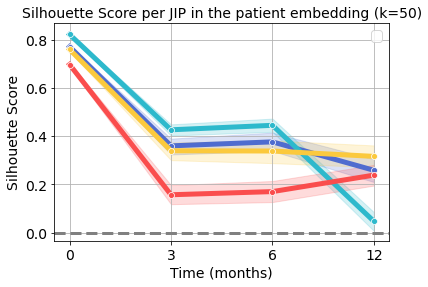

In [6]:
pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D'];
df_stability = pd.DataFrame(results)

#sns.lineplot(data=df_stability, x="Time Point", y="Ratio_between_within", hue="Cluster")
sns.lineplot(x='Time Point', y='Silhouette_score', hue='Cluster', data=df_stability, marker='o', linewidth=5, palette=pal_colorblind)

# Optional: Customize the plot
therapy = 'y'
plt.xticks([1, 2, 3, 4], ["0", "3", "6", "12"], fontsize=14) 
plt.yticks(fontsize=14)
plt.title("Silhouette Score per JIP in the patient embedding (k=50)", fontsize=14)
plt.xlabel("Time (months)", fontsize=14) 
plt.ylabel('Silhouette Score', fontsize=14)  #  (Ratio BCSS vs WCSS)
plt.legend([],fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=3)
#plt.ylim([-.5,1])
plt.grid(True)

## conduct 1,000 permutations to infer significance

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind
from scipy.stats import percentileofscore
from scipy.stats import mannwhitneyu

# Comparing random scores of Cluster 0 vs Cluster 1
#stat, p_val = mannwhitneyu(dist_cluster_0, dist_cluster_1)
#print(f"Mann-Whitney P-value: {p_val:.5f}")

def t_test(x,y,alternative='both-sided'):
    """
    Description:
        Perform a t-test, either one- or two-sided
    """
    stats, double_p = ttest_ind(list(x),list(y),equal_var = False)

    if alternative == 'both-sided':
        pval = double_p
    elif alternative == 'greater':
        if np.mean(x) > np.mean(y):
            pval = double_p/2.
        else:
            pval = 1.0 - double_p/2.
    elif alternative == 'less':
        if np.mean(x) < np.mean(y):
            pval = double_p/2.
        else:
            pval = 1.0 - double_p/2.
    return stats, pval

def perm_test(x,y):
    # Inside your plotting loop:
    dist = x

    # Non-parametric P-value calculation
    count_better = np.sum(dist >= np.median(y))
    emp_p_val = (count_better + 1) / (len(dist) + 1)

    # Non-parametric Effect Size: Percentile Rank
    # Tells you exactly where your score sits (e.g., 99th percentile)
    
    rank = percentileofscore(dist, actual_val)
    
    return rank, emp_p_val

    #text_str = f'Empirical P-val: {emp_p_val:.4f}\nPercentile Rank: {rank:.1f}%'

# --- 3. Run 1000 Random Permutations ---
n_permutations = 1000

results = []

TIME = 4

np.random.seed(777)
cluster_map = df_raw[df_raw['visnr'] == 1].set_index('PATNR')['Original_cluster'].to_dict()


for i in range(n_permutations):
    df_visit = df_raw[df_raw["visnr"] == TIME].copy().set_index('PATNR')
    df_visit['Original_cluster'] = df_visit.index.map(cluster_map)
     # Drop patients who weren't there at baseline or have no cluster
    df_visit = df_visit.dropna(subset=['Original_cluster'])  
    
    df_visit['Original_cluster'] = np.random.randint(1, 5, size=len(df_visit['Original_cluster']))
    
    if len(df_visit) < 2: continue

    # Calculate full distance matrix for the visit
    X_visit = df_visit[lf_col].values
    D_visit = pairwise_distances(X_visit, metric='cosine')
    
    # Get indices for each cluster present at this visit
    cluster_indices = df_visit.groupby('Original_cluster').indices
    
    # Run the manual function
    #individual_ss = one_vs_rest_silhouette(D_visit, df_visit['Original_cluster'].values)
    
    # Run the manual function
    individual_ss, within_distances, between_distances = one_vs_rest_silhouette_distances(D_visit, df_visit['Original_cluster'].values)

    # 2. Add these scores back to your visit dataframe so we can group them
    df_visit['patient_ss'] = individual_ss
    df_visit['patient_within'] = within_distances
    df_visit['patient_between'] = between_distances

    # 3. Now, when you iterate through your clusters:
    for cluster_id, member_indices in cluster_indices.items():
        if len(member_indices) < 2: continue
            
        # Get the individual scores for just this cluster
        cluster_scores = df_visit[df_visit['Original_cluster'] == cluster_id]['patient_ss']
        within_scores = df_visit[df_visit['Original_cluster'] == cluster_id]['patient_within']
        between_scores = df_visit[df_visit['Original_cluster'] == cluster_id]['patient_between']
        
        for i in range(len(cluster_scores)):
            results.append({
                "Time Point": time,
                "Cluster": cluster_id,
                "Individual_SS": cluster_scores.iloc[i],  # Raw score per patient
                "Individual_W": within_scores.iloc[i],  # Raw score per patient
                "Individual_B": between_scores.iloc[i],  # Raw score per patient
            })
    




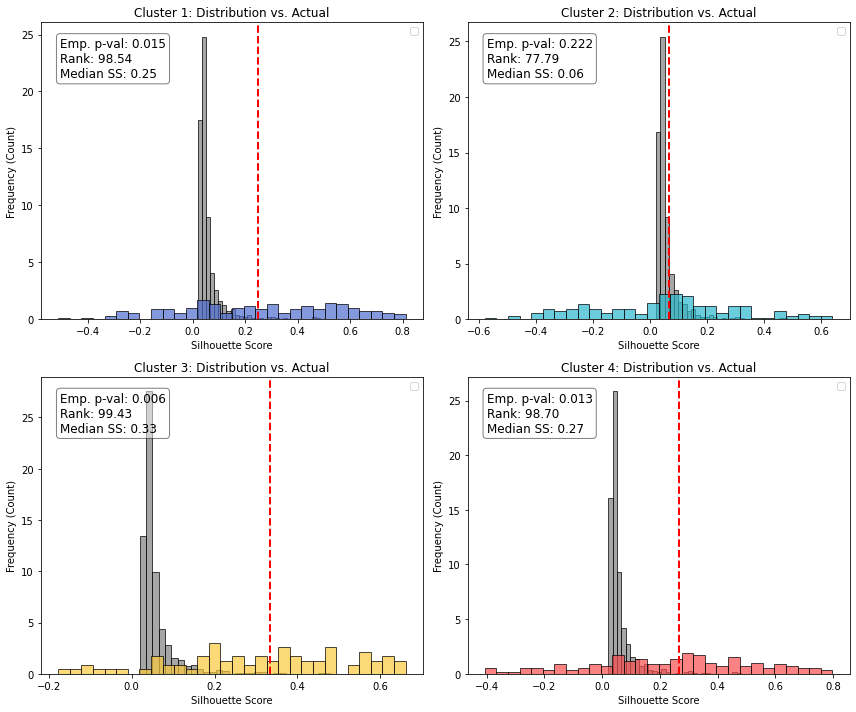

In [50]:
df_stability_perm = pd.DataFrame(results)
df_stability_perm['Ratio_between_within'] = df_stability_perm['Individual_B'] / df_stability_perm['Individual_W']
df_stability_perm['Ratio_within_between'] = df_stability_perm['Individual_W'] / df_stability_perm['Individual_B']
df_stability_perm


# Now for actual cluster data we only compare last visit 5
df_last_visit = df_jips[df_jips['Time Point']==4].copy()
df_last_visit = df_last_visit.rename(columns={'Silhouette_score': 'Individual_W'})
df_last_visit['Cluster'] = df_last_visit['Cluster'] + 1

# Assuming your dataframe is named 'df'
pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D'];

clusters = df_stability_perm['Cluster'].unique()

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, cluster_id in enumerate(clusters):
    # Filter for the specific cluster permutations
    cluster_data_perm = df_stability_perm[df_stability_perm['Cluster'] == cluster_id]
    cluster_data = df_last_visit[(df_last_visit['Cluster'] == cluster_id)].copy()
    
    # 1. Plot the histogram of random permutation scores
    axes[int(cluster_id)-1].hist(cluster_data_perm['Individual_W'], bins=30, 
                 color='gray', edgecolor='black', alpha=0.7, 
                 label='Random Permutations', density=True)
    axes[int(cluster_id)-1].hist(cluster_data['Individual_W'], bins=30, 
                 color=pal_colorblind[int(cluster_id)-1], edgecolor='black', alpha=0.7, 
                 label='Actual cluster', density=True)
    
    # Get mean reference ss
    actual_val = cluster_data['Individual_W'].median()
    
    
    # 2. Add the reference SS line for the actual cluster
    #actual_val = reference_ss_list[i]
    axes[int(cluster_id)-1].axvline(actual_val, color='red', linestyle='--', linewidth=2, 
                    label=f'Actual SS: {actual_val:.3f}')
    
    # Formatting
    axes[int(cluster_id)-1].set_title(f'Cluster {cluster_id}: Distribution vs. Actual')
    axes[int(cluster_id)-1].set_xlabel('Silhouette Score')
    axes[int(cluster_id)-1].set_ylabel('Frequency (Count)')
    axes[int(cluster_id)-1].legend([])
    
    # Perform one tailed t-test
    #tstat, pval = t_test(cluster_data['Individual_SS'], cluster_data_perm['Individual_SS'], alternative='greater')
    tstat, pval = perm_test(cluster_data_perm['Individual_W'], cluster_data['Individual_W'])
   
    # --- ANNOTATION BLOCK ---
    # We use transform=ax.transAxes so (0,0) is bottom-left and (1,1) is top-right
    text_str = f'Emp. p-val: {pval:.3f}\nRank: {tstat:.2f}\nMedian SS: {actual_val:.2f}'

    axes[int(cluster_id)-1].text(0.05, 0.95, text_str, 
            transform=axes[int(cluster_id)-1].transAxes, 
            fontsize=12,
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    # -------------------------

plt.tight_layout()
plt.show()

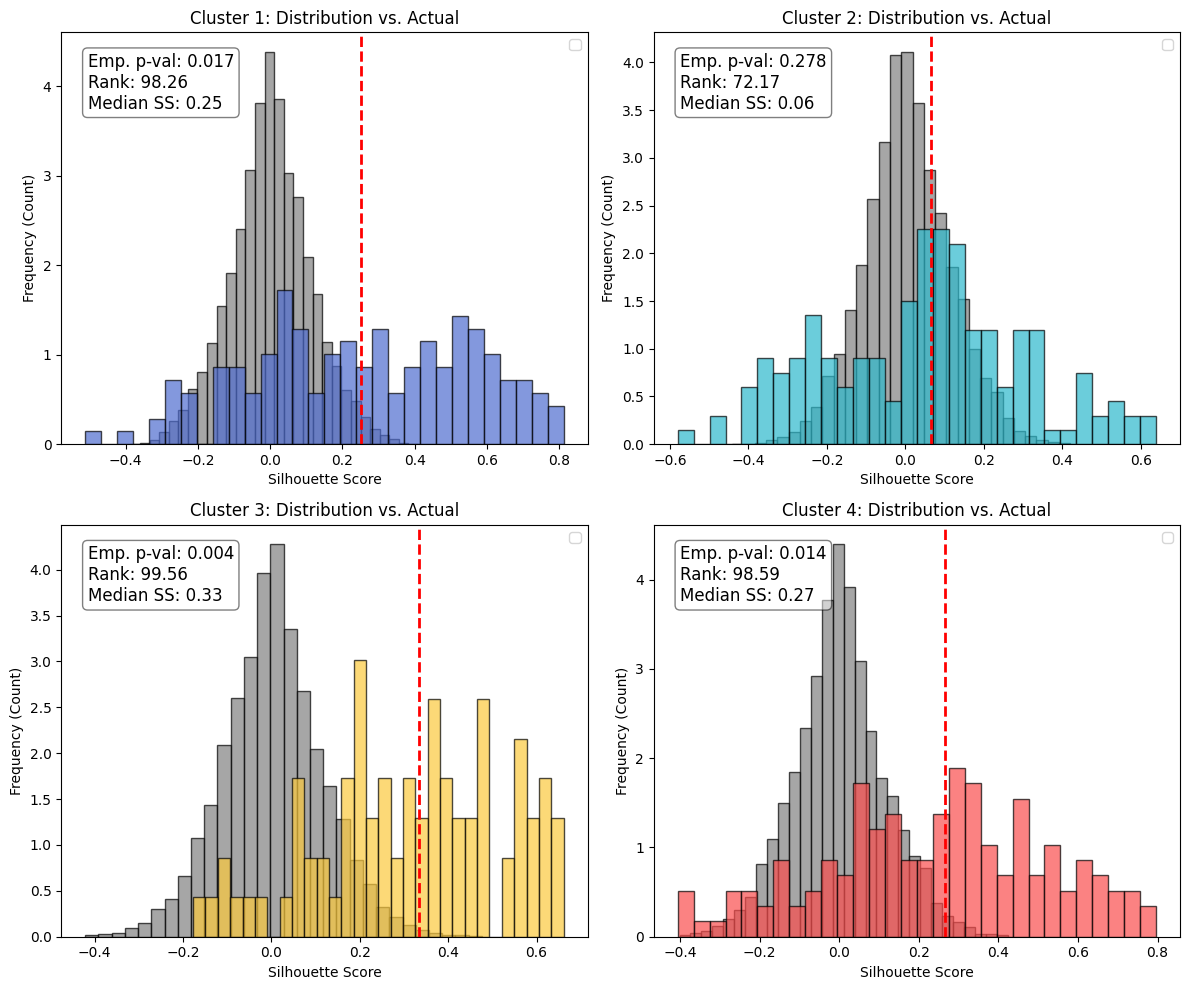

In [18]:
df_stability_perm = pd.DataFrame(results)


# Now for actual cluster data we only compare last visit 5
df_last_visit = df_stability[df_stability['Time Point']==4].copy()
df_last_visit = df_last_visit.rename(columns={'Silhouette_score': 'Individual_SS'})
df_last_visit['Cluster'] = df_last_visit['Cluster'] + 1

# Assuming your dataframe is named 'df'
pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D'];

clusters = df_stability_perm['Cluster'].unique()

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, cluster_id in enumerate(clusters):
    # Filter for the specific cluster permutations
    cluster_data_perm = df_stability_perm[df_stability_perm['Cluster'] == cluster_id]
    cluster_data = df_last_visit[(df_last_visit['Cluster'] == cluster_id)].copy()
    
    # 1. Plot the histogram of random permutation scores
    axes[int(cluster_id)-1].hist(cluster_data_perm['Individual_SS'], bins=30, 
                 color='gray', edgecolor='black', alpha=0.7, 
                 label='Random Permutations', density=True)
    axes[int(cluster_id)-1].hist(cluster_data['Individual_SS'], bins=30, 
                 color=pal_colorblind[int(cluster_id)-1], edgecolor='black', alpha=0.7, 
                 label='Actual cluster', density=True)
    
    # Get mean reference ss
    actual_val = cluster_data['Individual_SS'].median()
    
    
    # 2. Add the reference SS line for the actual cluster
    #actual_val = reference_ss_list[i]
    axes[int(cluster_id)-1].axvline(actual_val, color='red', linestyle='--', linewidth=2, 
                    label=f'Actual SS: {actual_val:.3f}')
    
    # Formatting
    axes[int(cluster_id)-1].set_title(f'Cluster {cluster_id}: Distribution vs. Actual')
    axes[int(cluster_id)-1].set_xlabel('Silhouette Score')
    axes[int(cluster_id)-1].set_ylabel('Frequency (Count)')
    axes[int(cluster_id)-1].legend([])
    
    # Perform one tailed t-test
    #tstat, pval = t_test(cluster_data['Individual_SS'], cluster_data_perm['Individual_SS'], alternative='greater')
    tstat, pval = perm_test(cluster_data_perm['Individual_SS'], cluster_data['Individual_SS'])
   
    # --- ANNOTATION BLOCK ---
    # We use transform=ax.transAxes so (0,0) is bottom-left and (1,1) is top-right
    text_str = f'Emp. p-val: {pval:.3f}\nRank: {tstat:.2f}\nMedian SS: {actual_val:.2f}'

    axes[int(cluster_id)-1].text(0.05, 0.95, text_str, 
            transform=axes[int(cluster_id)-1].transAxes, 
            fontsize=12,
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    # -------------------------

plt.tight_layout()
plt.show()

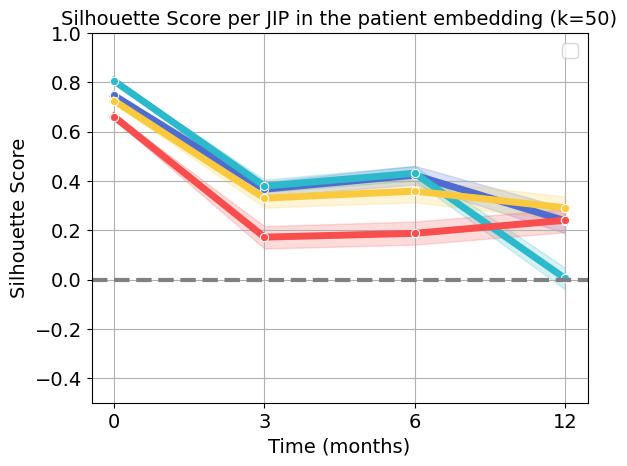

In [376]:
pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D'];
df_stability = pd.DataFrame(results)

#sns.lineplot(data=df_stability, x="Time Point", y="Ratio_between_within", hue="Cluster")
sns.lineplot(x='Time Point', y='Silhoette_score', hue='Cluster', data=df_stability, marker='o', linewidth=5, palette=pal_colorblind)

# Optional: Customize the plot
therapy = 'y'
plt.xticks([1, 2, 3, 4], ["0", "3", "6", "12"], fontsize=14) 
plt.yticks(fontsize=14)
plt.title("Silhouette Score per JIP in the patient embedding (k=50)", fontsize=14)
plt.xlabel("Time (months)", fontsize=14) 
plt.ylabel('Silhouette Score', fontsize=14)  #  (Ratio BCSS vs WCSS)
plt.legend([],fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=3)
plt.ylim([-.5,1])
plt.grid(True)

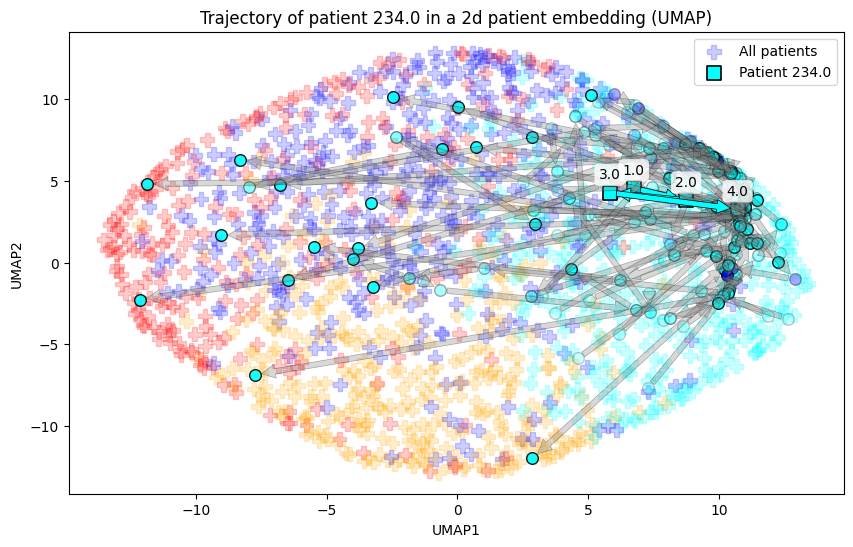

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ANNOTATE = True
PLOT_ARROW = True
PLOT_ARROW_PATIENT = True
COLOR_BG = True
COLOR_CLUSTER = True

# Select the patient to highlight
selected_patient_id = 234.0 #'226.0' # 5302 #'3021'#'3309'

# Sample data: assume df contains PCA components, patient IDs, and visit dates
data_plot = {
    'patient_id': df_meta_full['PATNR'].astype(str),
    'visit_date': df_meta_full['visnr_x'].fillna(0),
    'cluster': df_meta_full['Original_cluster'],
    'PCA1': X_embedded[:,0],
    'PCA2': X_embedded[:,1]
}
df_plot = pd.DataFrame(data_plot)



# Get neighbours
l_neighbours = baseline_neighbours[selected_patient_id]#[:2]

# Filter and sort the data for the selected patient
patient_data = df_plot[df_plot['patient_id'] == str(selected_patient_id)].sort_values(by='visit_date')

# Plot all PCA points

# Map the cluster values to their corresponding colors
if COLOR_CLUSTER:
    d_cluscol = {3.0 : 'red', 2.0 : 'orange',1.0 : 'cyan', 0.0 :'blue'}
else :
    d_cluscol = {3.0 : 'blue', 2.0 : 'blue',1.0 : 'blue', 0.0 :'blue'}
colors = df_plot[:1387]['cluster'].map(d_cluscol)
colors_bg = df_plot[:1387]['cluster'].map({3.0 : 'red', 2.0 : 'orange',1.0 : 'cyan', 0.0 :'blue'})

plt.figure(figsize=(10, 6))
if COLOR_BG:
    plt.scatter(df_plot[:1387]['PCA1'], df_plot[:1387]['PCA2'], c=colors_bg, label='All patients', s=100, alpha=0.2, marker='P')
else :
    plt.scatter(df_plot[:1387]['PCA1'], df_plot[:1387]['PCA2'], c='lightgrey', label='All patients')
d_color = {1.0 : 'red', 2.0 : 'orange', 3.0 : 'yellow', 4.0 :'cyan', 5.0 : 'green'}

for pid in l_neighbours:
    neighbour_data = df_plot[df_plot['patient_id'] == str(pid)].sort_values(by='visit_date')
    x = neighbour_data['PCA1'].values
    y = neighbour_data['PCA2'].values
    
    
    #plt.scatter(neighbour_data['PCA1'], neighbour_data['PCA2'], c=colors, label=f'Patient {pid}')
    
    # 1. Normalize visit dates to a 0.2 - 1.0 range for alpha
    # This ensures the first visit isn't completely invisible (0.0)
    v_min, v_max = neighbour_data['visit_date'].min(), neighbour_data['visit_date'].max()
    
    # If there's only one visit, set alpha to 1.0; otherwise, scale it
    if v_max == v_min:
        alphas = pd.Series([0.8] * len(neighbour_data))
    else:
        alphas = 0.2 + 0.4 * (neighbour_data['visit_date'] - v_min) / (v_max - v_min)
    #print(alphas)
    if len(alphas) > 0:
        alphas.iloc[-1] = 0.9 # ensure last item is always 1 (not larger)

    # 2. Plotting the points with varying opacity
    # Note: plt.scatter 'c' can be a single color, but 'alpha' must be applied
    # specifically if you want it to vary per point. 
    # The easiest way is to use a RGBA color array:
    for i in range(len(x)):
        plt.scatter(x[i], y[i], color=d_cluscol[neighbour_data['cluster'].iloc[0]], alpha=alphas.iloc[i], s=70, edgecolors='black',)
    
    #plt.plot(neighbour_data['PCA1'], neighbour_data['PCA2'], c='grey', linestyle='--')
    if PLOT_ARROW:
        for i in range(len(x) - 1):
            plt.annotate('', 
                         xy=(x[i+1], y[i+1]),      # Tip of the arrow
                         xytext=(x[i], y[i]),      # Tail of the arrow
                         arrowprops=dict(
                             arrowstyle='simple',
                             #linestyle='--',       # Your requested dashed style
                             facecolor='grey',
                             edgecolor='black',         # Neutral color so point colors pop
                             linewidth=0.5,
                             #alpha=0.7,
                             alpha=0.3,
                             mutation_scale=20,     # Controls the size of the arrow head
                             shrinkA=5,             # Small gap from start point
                             shrinkB=5,           # Small gap from end point
                             #alpha=alphas.iloc[i]
                         ))

# Plot the selected patient's visits with a distinct color
plt.scatter(patient_data['PCA1'], patient_data['PCA2'], c=d_cluscol[patient_data['cluster'].iloc[0]], label=f'Patient {selected_patient_id}',marker='s', s=100, edgecolors='black',
        linewidths=1.2)        
     
# Now also for selected patient
x = patient_data['PCA1'].values
y = patient_data['PCA2'].values

if PLOT_ARROW_PATIENT:
    for i in range(len(x) - 1):
        plt.annotate('', 
                     xy=(x[i+1], y[i+1]),      # Tip of the arrow
                     xytext=(x[i], y[i]),      # Tail of the arrow
                     arrowprops=dict(
                         #arrowstyle='->',      # Simple arrow head
                         arrowstyle='simple',
                         #linestyle='--',       # Your requested dashed style
                         facecolor=d_cluscol[patient_data['cluster'].iloc[0]],
                         edgecolor='black',         # Neutral color so point colors pop
                         linewidth=0.5,
                         alpha=1,
                         mutation_scale=20,     # Controls the size of the arrow head
                         shrinkA=5,             # Small gap from start point
                         shrinkB=5              # Small gap from end point
                     ))

    
# Annotate the points with visit dates

if ANNOTATE:

    for i, row in patient_data.iterrows():
        plt.annotate(row['visit_date'], (row['PCA1'], row['PCA2']), textcoords="offset points", xytext=(0,10), ha='center', bbox=dict(boxstyle='round,pad=0.3', 
                           fc='white',   # Face color
                           ec='none',    # Edge color (none for no border)
                           alpha=0.8)   # Opacity of the background)
                )


# Draw a line through the visits in chronological order
#plt.plot(patient_data['PCA1'], patient_data['PCA2'], c='blue', linestyle='--', marker='o')

    
# Add labels and legend
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Trajectory of patient %s in a 2d patient embedding (UMAP)' % (selected_patient_id))
plt.legend()
plt.show()

### Create functions for Silhouette score (traditional and one versus rest)

In [32]:
import numpy as np
import pandas as pd

def one_vs_rest_silhouette(D_visit, cluster_labels):
    n_samples = D_visit.shape[0]
    ovr_scores = np.zeros(n_samples)
    unique_clusters = np.unique(cluster_labels)
    
    for i in range(n_samples):
        current_cluster = cluster_labels[i]
        
        # Get indices for SAME cluster and OTHER clusters
        same_cluster_idx = np.where(cluster_labels == current_cluster)[0]
        other_clusters_idx = np.where(cluster_labels != current_cluster)[0]
        
        # --- 1. a_i (Cohesion) ---
        # Mean distance to others in same cluster (exclude self)
        mask_a = same_cluster_idx[same_cluster_idx != i]
        a_i = D_visit[i, mask_a].mean() if len(mask_a) > 0 else 0
        
        # --- 2. b_i (One-vs-Rest Separation) ---
        # Mean distance to EVERYONE not in the current cluster
        if len(other_clusters_idx) > 0:
            b_i = D_visit[i, other_clusters_idx].mean()
        else:
            b_i = 0
            
        # --- 3. s_i (One-vs-Rest Score) ---
        ovr_scores[i] = (b_i - a_i) / max(a_i, b_i) if max(a_i, b_i) > 0 else 0
        
    return ovr_scores

def one_vs_rest_silhouette_distances(D_visit, cluster_labels):
    n_samples = D_visit.shape[0]
    ovr_scores = np.zeros(n_samples)
    within_scores = np.zeros(n_samples)
    between_scores = np.zeros(n_samples)
    unique_clusters = np.unique(cluster_labels)
    
    for i in range(n_samples):
        current_cluster = cluster_labels[i]
        
        # Get indices for SAME cluster and OTHER clusters
        same_cluster_idx = np.where(cluster_labels == current_cluster)[0]
        other_clusters_idx = np.where(cluster_labels != current_cluster)[0]
        
        # --- 1. a_i (Cohesion) ---
        # Mean distance to others in same cluster (exclude self)
        mask_a = same_cluster_idx[same_cluster_idx != i]
        a_i = D_visit[i, mask_a].mean() if len(mask_a) > 0 else 0
        
        # --- 2. b_i (One-vs-Rest Separation) ---
        # Mean distance to EVERYONE not in the current cluster
        if len(other_clusters_idx) > 0:
            b_i = D_visit[i, other_clusters_idx].mean()
        else:
            b_i = 0
            
        # --- 3. s_i (One-vs-Rest Score) ---
        ovr_scores[i] = (b_i - a_i) / max(a_i, b_i) if max(a_i, b_i) > 0 else 0
        within_scores[i] = a_i if a_i > 0 else 0
        between_scores[i] = b_i
        
    return ovr_scores, within_scores, between_scores


def manual_silhouette_samples(D_visit, cluster_labels):
    """
    D_visit: precomputed distance matrix (n_samples x n_samples)
    cluster_labels: array/series of cluster assignments
    """
    n_samples = D_visit.shape[0]
    individual_scores = np.zeros(n_samples)
    unique_clusters = np.unique(cluster_labels)
    
    # Create a mapping of cluster names to their indices for speed
    cluster_indices = {c: np.where(cluster_labels == c)[0] for c in unique_clusters}

    for i in range(n_samples):
        current_cluster = cluster_labels[i]
        members_same_cluster = cluster_indices[current_cluster]
        
        # --- 1. Calculate a_i ---
        # Mask out the point itself (distance to self is 0)
        mask_a = members_same_cluster[members_same_cluster != i]
        
        if len(mask_a) > 0:
            a_i = D_visit[i, mask_a].mean()
        else:
            # Silhouette is technically 0 if a cluster has only 1 member
            individual_scores[i] = 0
            continue

        # --- 2. Calculate b_i ---
        other_cluster_averages = []
        for other_cluster in unique_clusters:
            if other_cluster == current_cluster:
                continue
                
            members_other_cluster = cluster_indices[other_cluster]
            if len(members_other_cluster) > 0:
                dist_to_other = D_visit[i, members_other_cluster].mean()
                other_cluster_averages.append(dist_to_other)
        
        # Separation is the distance to the NEAREST neighboring cluster
        b_i = min(other_cluster_averages) if other_cluster_averages else 0

        # --- 3. Calculate s_i ---
        # Formula: (b - a) / max(a, b)
        individual_scores[i] = (b_i - a_i) / max(a_i, b_i) if max(a_i, b_i) > 0 else 0
        
    return individual_scores

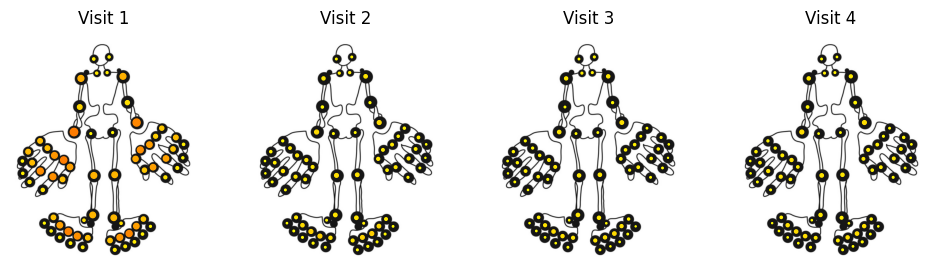

In [38]:
import importlib as imp
import sys
sys.path.append(r'src/')
import FunctionsRecurrence as rec
imp.reload(rec)
rec.plotGestaltEvolution(df_fu, n_visits=4, scaling=True, category='Pijn') # , category='Pijn'